## Question - 1
### $E_k = E_0 + 2t\cos{ka} \pm t^{'}$
### Metal-insulator transition happens at $\frac{t}{t^{\prime}} = 0.5$

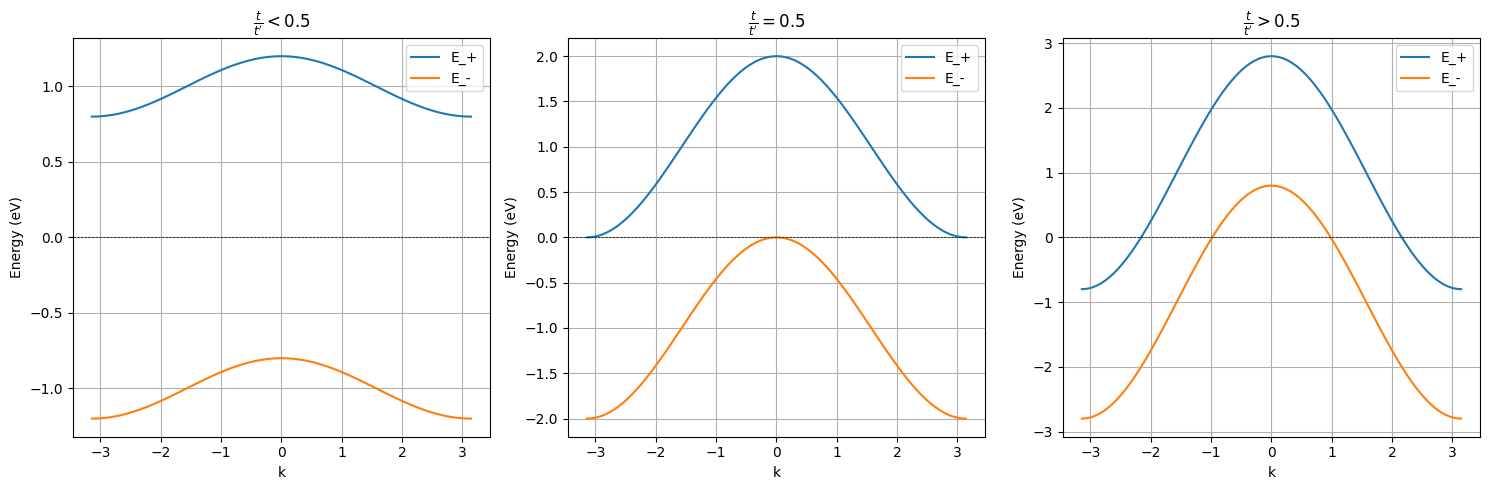

In [1]:
import numpy as np
import matplotlib.pyplot as plt
#WLOG E_0 = 0

def f_p(k,t=0.5,t_p = 1):
    return 2*t*np.cos(k) + t_p

def f_m(k,t=0.5,t_p = 1):
    return 2*t*np.cos(k) - t_p

k = np.linspace(-np.pi, np.pi, 100)
# Create a figure with 1 row and 3 columns, setting an appropriate width
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# --- Plot 1: t/t' < 0.5 ---
axs[0].plot(k, f_p(k, t=0.1, t_p=1), label='E_+')
axs[0].plot(k, f_m(k, t=0.1, t_p=1), label='E_-')
axs[0].set_xlabel('k')
axs[0].set_ylabel('Energy (eV)')
axs[0].axhline(0, color='black', lw=0.5, ls='--')
axs[0].set_title(r'$\frac{t}{t^{\prime}} < 0.5$')
axs[0].legend()
axs[0].grid(True)

# --- Plot 2: t/t' = 0.5 ---
# Note: I added explicit arguments t=0.5, t_p=1 here for consistency, 
# assuming your default arguments were set to this.
axs[1].plot(k, f_p(k, t=0.5, t_p=1), label='E_+')
axs[1].plot(k, f_m(k, t=0.5, t_p=1), label='E_-')
axs[1].set_xlabel('k')
axs[1].set_ylabel('Energy (eV)')
axs[1].axhline(0, color='black', lw=0.5, ls='--')
axs[1].set_title(r'$\frac{t}{t^{\prime}} = 0.5$')
axs[1].legend()
axs[1].grid(True)

# --- Plot 3: t/t' > 0.5 ---
axs[2].plot(k, f_p(k, t=0.9, t_p=1), label='E_+')
axs[2].plot(k, f_m(k, t=0.9, t_p=1), label='E_-')
axs[2].set_xlabel('k')
axs[2].set_ylabel('Energy (eV)')
axs[2].axhline(0, color='black', lw=0.5, ls='--')
axs[2].set_title(r'$\frac{t}{t^{\prime}} > 0.5$')
axs[2].legend()
axs[2].grid(True)

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()


## Question-2
### a) $E_k = E_0 + 2t\cos{k} \pm \sqrt{{t^{'}}^{2} + {t^{''}}^{2} + 2t^{'}t^{''}\cos{k}}$
### b) $E_k = E_0 + 2t\cos{k} \pm |{t^{'}} + 2t^{''}\cos{k}|$


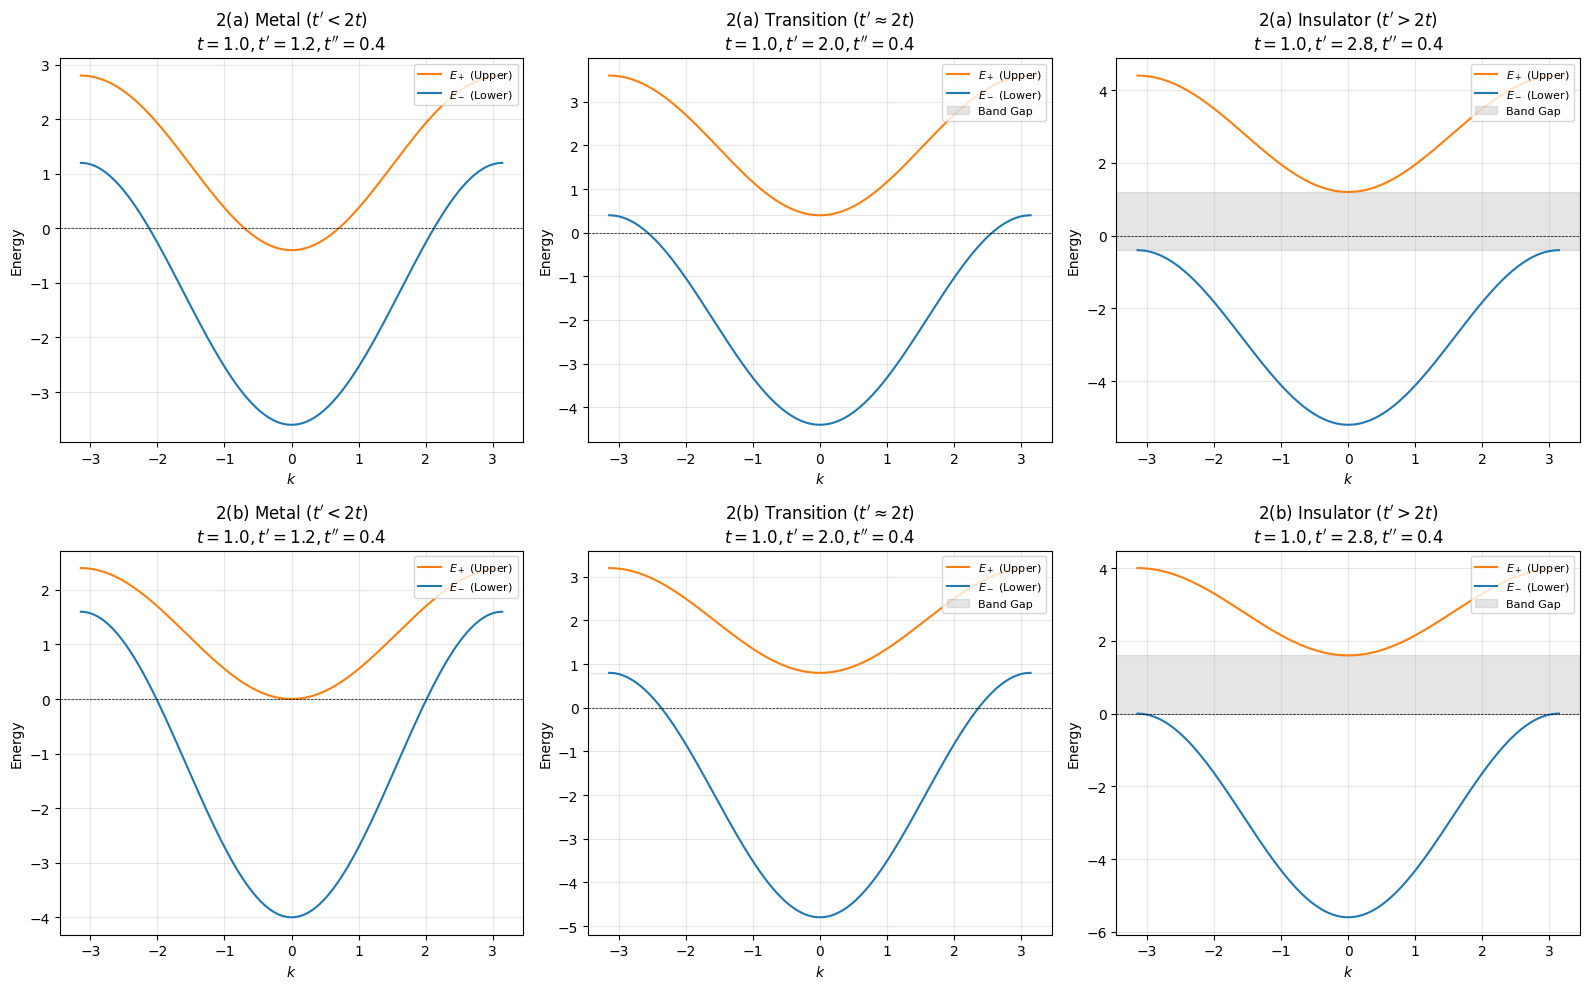

In [2]:

# --- Define the dispersion relations ---

def E_a_plus(k, t, t_prime, t_double_prime):
    """Upper band for 2(a) Single Diagonal Hopping"""
    # Using the positive root for the upper band
    return -2 * t * np.cos(k) + np.sqrt(t_prime**2 + t_double_prime**2 + 2 * t_prime * t_double_prime * np.cos(k))

def E_a_minus(k, t, t_prime, t_double_prime):
    """Lower band for 2(a) Single Diagonal Hopping"""
    # Using the negative root for the lower band
    return -2 * t * np.cos(k) - np.sqrt(t_prime**2 + t_double_prime**2 + 2 * t_prime * t_double_prime * np.cos(k))

def E_b_plus(k, t, t_prime, t_double_prime):
    """Upper band for 2(b) Cross-Diagonal Hopping"""
    return -2 * t * np.cos(k) + np.abs(t_prime + 2 * t_double_prime * np.cos(k))

def E_b_minus(k, t, t_prime, t_double_prime):
    """Lower band for 2(b) Cross-Diagonal Hopping"""
    return -2 * t * np.cos(k) - np.abs(t_prime + 2 * t_double_prime * np.cos(k))


# --- Setup Parameters ---
# We keep t = 1 and t'' = 0.4 (ensuring t'' < t and t')
t_val = 1.0
t_dp = 0.4 
k_vals = np.linspace(-np.pi, np.pi, 200)

# To show the transition, we vary t'
# The gap generally closes around t' = 2t depending on the specific geometry
t_primes = [1.2, 2.0, 2.8] 
titles = ["Metal ($t' < 2t$)", "Transition ($t' \\approx 2t$)", "Insulator ($t' > 2t$)"]

# --- Create the Plots ---
fig, axs = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: Part 2(a) Single Diagonal
for i, t_p in enumerate(t_primes):
    axs[0, i].plot(k_vals, E_a_plus(k_vals, t_val, t_p, t_dp), label='$E_+$ (Upper)', color='C1')
    axs[0, i].plot(k_vals, E_a_minus(k_vals, t_val, t_p, t_dp), label='$E_-$ (Lower)', color='C0')
    
    # Fill between the min of upper and max of lower to highlight the gap/overlap
    max_lower = np.max(E_a_minus(k_vals, t_val, t_p, t_dp))
    min_upper = np.min(E_a_plus(k_vals, t_val, t_p, t_dp))
    if min_upper > max_lower:
        axs[0, i].axhspan(max_lower, min_upper, color='gray', alpha=0.2, label='Band Gap')
    
    axs[0, i].set_title(f"2(a) {titles[i]}\n$t={t_val}, t'={t_p}, t''={t_dp}$")
    axs[0, i].set_ylabel('Energy')
    axs[0, i].set_xlabel('$k$')
    axs[0, i].axhline(0, color='black', lw=0.5, ls='--')
    axs[0, i].grid(True, alpha=0.3)
    axs[0, i].legend(loc='upper right', fontsize=8)

# Row 2: Part 2(b) Cross Diagonal
for i, t_p in enumerate(t_primes):
    axs[1, i].plot(k_vals, E_b_plus(k_vals, t_val, t_p, t_dp), label='$E_+$ (Upper)', color='C1')
    axs[1, i].plot(k_vals, E_b_minus(k_vals, t_val, t_p, t_dp), label='$E_-$ (Lower)', color='C0')
    
    max_lower = np.max(E_b_minus(k_vals, t_val, t_p, t_dp))
    min_upper = np.min(E_b_plus(k_vals, t_val, t_p, t_dp))
    if min_upper > max_lower:
        axs[1, i].axhspan(max_lower, min_upper, color='gray', alpha=0.2, label='Band Gap')

    axs[1, i].set_title(f"2(b) {titles[i]}\n$t={t_val}, t'={t_p}, t''={t_dp}$")
    axs[1, i].set_ylabel('Energy')
    axs[1, i].set_xlabel('$k$')
    axs[1, i].axhline(0, color='black', lw=0.5, ls='--')
    axs[1, i].grid(True, alpha=0.3)
    axs[1, i].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

## Question - 3
### a) $E_k = E_0 + 2t\cos{k_x a} + 2t\cos{k_y a}$
### b) $E_k = E_0 + 2t\cos{k_x a} + 2t\cos{k_y a} + 2t^{'}\cos{k_x a} \cos{k_y a}$

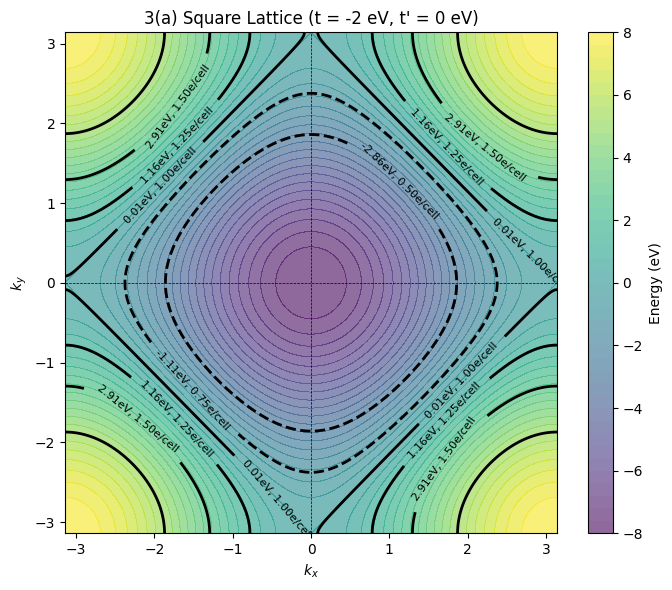

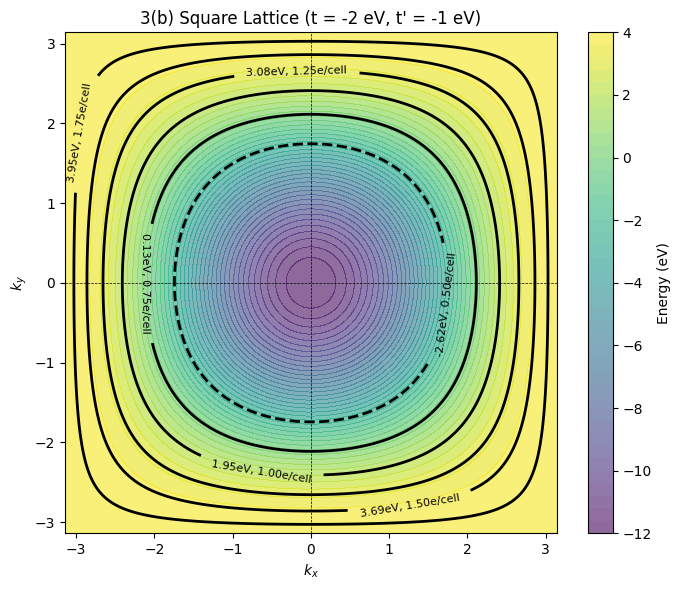

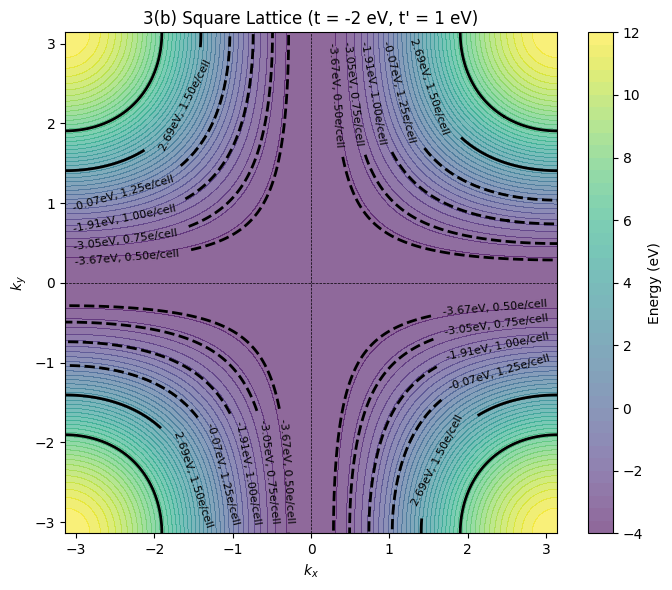

In [3]:


def calculate_energy(kx, ky, t, t_prime):
    """Calculates the tight-binding energy for a 2D square lattice."""
    return 2 * t * (np.cos(kx) + np.cos(ky)) + 4 * t_prime * np.cos(kx) * np.cos(ky)

def get_fermi_energy(E_flat, electrons_per_cell):
    """
    Finds the Fermi energy given an electron count.
    Max 2 electrons per unit cell (spin up + spin down).
    Filling fraction = electrons_per_cell / 2.0
    """
    filling_fraction = electrons_per_cell / 2.0
    # Ensure fraction doesn't exceed 1.0 (fully filled band)
    filling_fraction = min(filling_fraction, 1.0) 
    
    # The index corresponding to the filled states
    idx = int(filling_fraction * (len(E_flat) - 1))
    return E_flat[idx]

def plot_fermi_surfaces(t, t_prime, title):
    """Plots the contours for different electron fillings."""
    # Define the 1st Brillouin Zone
    k = np.linspace(-np.pi, np.pi, 400)
    kx, ky = np.meshgrid(k, k)
    
    # Calculate energy across the BZ
    E = calculate_energy(kx, ky, t, t_prime)
    
    # Sort energies to map electron count to Fermi levels
    E_flat_sorted = np.sort(E.flatten())
    
    electron_counts = np.arange(0.5, 2.25, 0.25) # 0.5 to 2.0 in steps of 0.25
    fermi_energies = []
    
    for ec in electron_counts:
        ef = get_fermi_energy(E_flat_sorted, ec)
        fermi_energies.append(ef)
        
    plt.figure(figsize=(7, 6))
    
    # Plot contour map of the band structure
    contour_bg = plt.contourf(kx, ky, E, levels=50, cmap='viridis', alpha=0.6)
    plt.colorbar(contour_bg, label='Energy (eV)')
    
    # Trace the Fermi curves
    # 1. Create a dictionary mapping each Fermi energy to its custom label
    fmt_dict = {ef: f'{ef:.2f}eV, {ec:.2f}e/cell' for ef, ec in zip(fermi_energies, electron_counts)}

    # 2. Plot the contour lines
    contour_lines = plt.contour(kx, ky, E, levels=fermi_energies, colors=['black'], linewidths=2)

    # 3. Pass the dictionary directly to the 'fmt' argument
    plt.clabel(contour_lines, inline=True, fontsize=8, fmt=fmt_dict)
        
    plt.title(title)
    plt.xlabel('$k_x$')
    plt.ylabel('$k_y$')
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
    plt.xlim(-np.pi, np.pi)
    plt.ylim(-np.pi, np.pi)
    plt.tight_layout()
    plt.show()



# 3(a) Nearest neighbour only
plot_fermi_surfaces(t=-2.0, t_prime=0.0, title="3(a) Square Lattice (t = -2 eV, t' = 0 eV)")

# 3(b) Add diagonal hopping t' = -1 eV
plot_fermi_surfaces(t=-2.0, t_prime=-1.0, title="3(b) Square Lattice (t = -2 eV, t' = -1 eV)")

# 3(b) Add diagonal hopping t' = 1 eV
plot_fermi_surfaces(t=-2.0, t_prime=1.0, title="3(b) Square Lattice (t = -2 eV, t' = 1 eV)")